
===== RANDOM FOREST =====
Accuracy : 0.9298245614035088
Precision: 0.9523809523809523
Recall   : 0.9345794392523364
F1 Score : 0.9433962264150944
ROC-AUC  : 0.9703563084112149

Confusion Matrix
[[ 59   5]
 [  7 100]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.92      0.91        64
           1       0.95      0.93      0.94       107

    accuracy                           0.93       171
   macro avg       0.92      0.93      0.93       171
weighted avg       0.93      0.93      0.93       171


===== VOTING ENSEMBLE =====
Accuracy : 0.9590643274853801
Precision: 0.9385964912280702
Recall   : 1.0
F1 Score : 0.9683257918552036
ROC-AUC  : 0.9871495327102804

Confusion Matrix
[[ 57   7]
 [  0 107]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        64
           1       0.94      1.00      0.97       107

    accuracy                           0

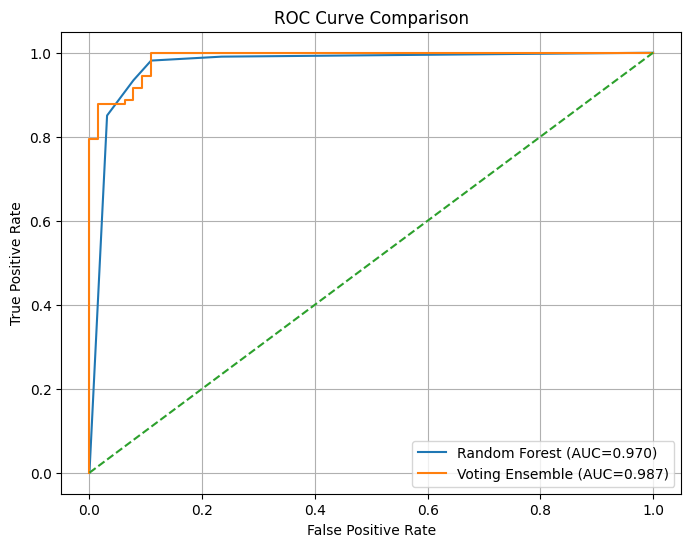

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Load dataset
X, y = load_breast_cancer(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ==========================
# Random Forest Classifier
# ==========================
rf = RandomForestClassifier(
    n_estimators=4,
    criterion='entropy',
    bootstrap=True,
    max_features='sqrt',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n===== RANDOM FOREST =====")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

# ==========================
# Voting Ensemble
# ==========================
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(max_iter=5000)
nb = GaussianNB()

voting_model = VotingClassifier(
    estimators=[
        ('dt', dt),
        ('lr', lr),
        ('nb', nb)
    ],
    voting='soft'   # use probabilities
)

voting_model.fit(X_train, y_train)

y_pred_vote = voting_model.predict(X_test)
y_prob_vote = voting_model.predict_proba(X_test)[:, 1]

print("\n===== VOTING ENSEMBLE =====")
print("Accuracy :", accuracy_score(y_test, y_pred_vote))
print("Precision:", precision_score(y_test, y_pred_vote))
print("Recall   :", recall_score(y_test, y_pred_vote))
print("F1 Score :", f1_score(y_test, y_pred_vote))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_vote))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_vote))

print("\nClassification Report")
print(classification_report(y_test, y_pred_vote))

# ==========================
# ROC Comparison Plot
# ==========================
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_vote, tpr_vote, _ = roc_curve(y_test, y_prob_vote)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})'
)

plt.plot(
    fpr_vote,
    tpr_vote,
    label=f'Voting Ensemble (AUC={roc_auc_score(y_test, y_prob_vote):.3f})'
)

plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()